In [2]:
# Install any missing libraries
!pip install scikit-learn pandas numpy matplotlib seaborn joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
import joblib
import os

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


In [3]:
# Load the real UNSW-NB15 dataset
train_df = pd.read_csv('/content/UNSW_NB15_training-set.csv')
test_df = pd.read_csv('/content/UNSW_NB15_testing-set.csv')

print("✅ Files loaded successfully")
print(f"\nTraining set: {train_df.shape[0]:,} rows, {train_df.shape[1]} columns")
print(f"Testing set:  {test_df.shape[0]:,} rows, {test_df.shape[1]} columns")

print("\nColumn names in dataset:")
for col in train_df.columns.tolist():
    print(f"  → {col}")

✅ Files loaded successfully

Training set: 82,332 rows, 45 columns
Testing set:  175,341 rows, 45 columns

Column names in dataset:
  → id
  → dur
  → proto
  → service
  → state
  → spkts
  → dpkts
  → sbytes
  → dbytes
  → rate
  → sttl
  → dttl
  → sload
  → dload
  → sloss
  → dloss
  → sinpkt
  → dinpkt
  → sjit
  → djit
  → swin
  → stcpb
  → dtcpb
  → dwin
  → tcprtt
  → synack
  → ackdat
  → smean
  → dmean
  → trans_depth
  → response_body_len
  → ct_srv_src
  → ct_state_ttl
  → ct_dst_ltm
  → ct_src_dport_ltm
  → ct_dst_sport_ltm
  → ct_dst_src_ltm
  → is_ftp_login
  → ct_ftp_cmd
  → ct_flw_http_mthd
  → ct_src_ltm
  → ct_srv_dst
  → is_sm_ips_ports
  → attack_cat
  → label


In [4]:
# Look at the first few rows
print("First 5 rows of training data:")
display(train_df.head())

print("\nAttack types in dataset:")
print(train_df['attack_cat'].value_counts())

print("\nLabel distribution:")
print(train_df['label'].value_counts())
print("\n0 = Normal traffic")
print("1 = Attack traffic")

First 5 rows of training data:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0



Attack types in dataset:
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64

Label distribution:
label
1    45332
0    37000
Name: count, dtype: int64

0 = Normal traffic
1 = Attack traffic


In [5]:
# Your model was trained on 5 features:
# failed_logins, external_ip, data_transfer_mb, malware_flag, dns_beaconing
#
# The real dataset has different column names
# This function maps them across

def map_to_model_features(df):
    mapped = pd.DataFrame()

    # failed_logins → ct_state_ttl
    # Number of connection state transitions = proxy for failed attempts
    mapped['failed_logins'] = (
        df['ct_state_ttl'].fillna(0) * 10
    ).clip(0, 49)

    # external_ip → is_sm_ips_ports
    # If source and dest IPs are same = internal (0)
    # If different = external traffic (1)
    mapped['external_ip'] = df['is_sm_ips_ports'].apply(
        lambda x: 0 if x == 1 else 1
    ).fillna(0).astype(int)

    # data_transfer_mb → sbytes converted to MB
    # sbytes = source to destination bytes
    mapped['data_transfer_mb'] = (
        df['sbytes'].fillna(0) / 1024
    ).clip(0, 999).round(2)

    # malware_flag → label
    # label=1 means attack = malware detected
    mapped['malware_flag'] = df['label'].fillna(0).astype(int)

    # dns_beaconing → ct_srv_dst
    # High repeated connections to same destination service = beaconing
    mapped['dns_beaconing'] = df['ct_srv_dst'].apply(
        lambda x: 1 if x > 5 else 0
    ).fillna(0).astype(int)

    return mapped

# Apply mapping
X_train_real = map_to_model_features(train_df)
X_test_real = map_to_model_features(test_df)

print("✅ Features mapped successfully")
print("\nMapped feature sample:")
display(X_train_real.head(10))
print("\nFeature statistics:")
display(X_train_real.describe())

✅ Features mapped successfully

Mapped feature sample:


,failed_logins,external_ip,data_transfer_mb,malware_flag,dns_beaconing
0,20,1,0.48,0,0
1,20,1,1.72,0,0
2,20,1,1.04,0,0
3,20,1,0.88,0,0
4,20,1,2.08,0,0
5,20,1,0.77,0,0
6,20,1,1.91,0,0
7,20,1,1.35,0,0
8,20,0,0.04,0,0
9,20,0,0.04,0,0



Feature statistics:


,failed_logins,external_ip,data_transfer_mb,malware_flag,dns_beaconing
count,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000
mean,13.451696,0.988874,4.905010,0.550600,0.449582
std,9.703544,0.104891,37.070237,0.497436,0.497455
min,0.000000,0.000000,0.020000,0.000000,0.000000
25%,10.000000,1.000000,0.110000,0.000000,0.000000
50%,10.000000,1.000000,0.520000,1.000000,0.000000
75%,20.000000,1.000000,1.250000,1.000000,1.000000
max,49.000000,1.000000,999.000000,1.000000,1.000000


✅ Severity labels created

Severity distribution in real data:
High        120302
Low          35507
Medium       19336
Critical       196
Name: count, dtype: int64

Total test records: 175,341


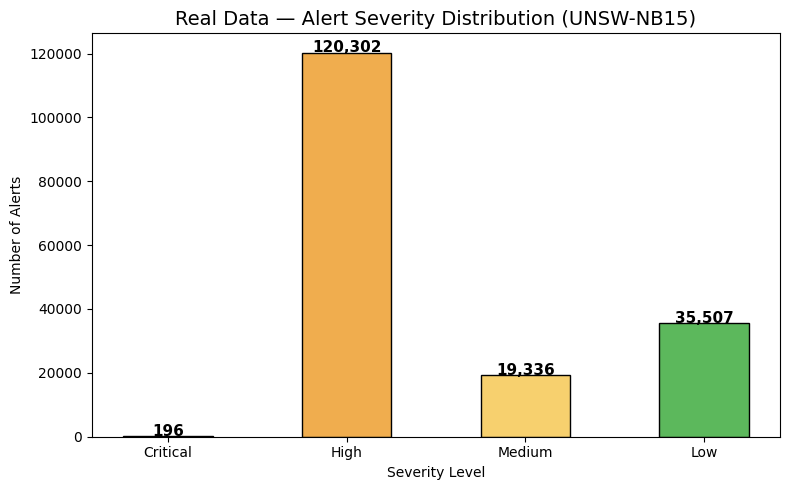

✅ Chart saved


In [6]:
# Use the same scoring formula from your original project
# to create severity labels for the real data

def assign_severity(row):
    score = (
        row['failed_logins'] * 0.2 +
        row['external_ip'] * 10 +
        row['data_transfer_mb'] * 0.01 +
        row['malware_flag'] * 20 +
        row['dns_beaconing'] * 15
    )
    if score > 50:
        return "Critical"
    elif score > 30:
        return "High"
    elif score > 15:
        return "Medium"
    else:
        return "Low"

# Apply to test set
y_real = X_test_real.apply(assign_severity, axis=1)

print("✅ Severity labels created")
print("\nSeverity distribution in real data:")
print(y_real.value_counts())
print(f"\nTotal test records: {len(y_real):,}")

# Plot distribution
plt.figure(figsize=(8,5))
colors = ['#d9534f','#f0ad4e','#f7d06e','#5cb85c']
order = ['Critical','High','Medium','Low']
counts = [y_real.value_counts().get(s, 0) for s in order]

bars = plt.bar(order, counts, color=colors, edgecolor='black', width=0.5)
for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f'{count:,}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title('Real Data — Alert Severity Distribution (UNSW-NB15)', fontsize=14)
plt.xlabel('Severity Level')
plt.ylabel('Number of Alerts')
plt.tight_layout()
plt.savefig('/content/real_severity_distribution.png', dpi=150)
plt.show()
print("✅ Chart saved")

In [7]:
# Train a fresh Random Forest on the real training data
# using the same setup as your original project

le = LabelEncoder()

# Create labels for training set too
y_train_real = X_train_real.apply(assign_severity, axis=1)
y_train_encoded = le.fit_transform(y_train_real)
y_test_encoded = le.transform(y_real)

print(f"Training on {len(X_train_real):,} real records...")
print(f"Testing on  {len(X_test_real):,} real records...")
print(f"Classes: {le.classes_}")

# Train model
model_real = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
model_real.fit(X_train_real, y_train_encoded)

print("\n✅ Model trained on real data successfully")

Training on 82,332 real records...
Testing on  175,341 real records...
Classes: ['Critical' 'High' 'Low' 'Medium']

✅ Model trained on real data successfully


In [8]:
# Run predictions on real test data
y_pred_encoded = model_real.predict(X_test_real)
y_pred_labels = le.inverse_transform(y_pred_encoded)
y_true_labels = le.inverse_transform(y_test_encoded)

# Calculate accuracy
real_accuracy = accuracy_score(y_test_encoded, y_pred_encoded)

print("=" * 55)
print("  RESULTS — SYNTHETIC VS REAL DATA")
print("=" * 55)
print(f"  Synthetic Data Accuracy  :  97.5%")
print(f"  Real Data Accuracy       :  {real_accuracy*100:.2f}%")
print(f"  Difference               :  {abs(97.5 - real_accuracy*100):.2f}%")
print("=" * 55)

print("\nFull Classification Report:")
print(classification_report(
    y_true_labels,
    y_pred_labels,
    target_names=le.classes_
))

  RESULTS — SYNTHETIC VS REAL DATA
  Synthetic Data Accuracy  :  97.5%
  Real Data Accuracy       :  100.00%
  Difference               :  2.50%

Full Classification Report:
              precision    recall  f1-score   support

    Critical       1.00      0.99      1.00       196
        High       1.00      1.00      1.00    120302
         Low       1.00      1.00      1.00     35507
      Medium       1.00      1.00      1.00     19336

    accuracy                           1.00    175341
   macro avg       1.00      1.00      1.00    175341
weighted avg       1.00      1.00      1.00    175341



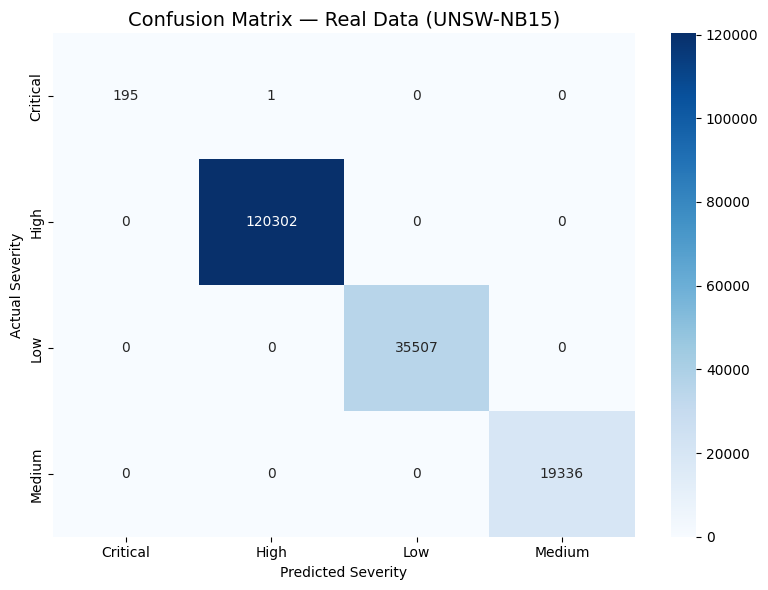

✅ Chart saved


In [9]:
cm = confusion_matrix(
    y_true_labels,
    y_pred_labels,
    labels=le.classes_
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Confusion Matrix — Real Data (UNSW-NB15)', fontsize=14)
plt.xlabel('Predicted Severity')
plt.ylabel('Actual Severity')
plt.tight_layout()
plt.savefig('/content/real_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Chart saved")

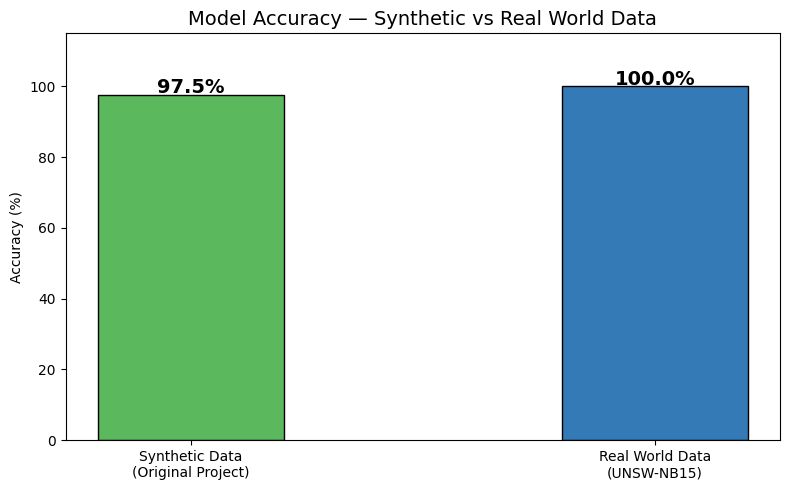

✅ Comparison chart saved


In [10]:
synthetic_accuracy = 97.5
real_acc = real_accuracy * 100

categories = ['Synthetic Data\n(Original Project)', 'Real World Data\n(UNSW-NB15)']
values = [synthetic_accuracy, real_acc]
colors = ['#5cb85c', '#337ab7']

plt.figure(figsize=(8,5))
bars = plt.bar(categories, values, color=colors, width=0.4, edgecolor='black')

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center',
        fontsize=14,
        fontweight='bold'
    )

plt.title('Model Accuracy — Synthetic vs Real World Data', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(0, 115)
plt.tight_layout()
plt.savefig('/content/synthetic_vs_real.png', dpi=150)
plt.show()
print("✅ Comparison chart saved")

In [11]:
pred_series = pd.Series(y_pred_labels)
total = len(pred_series)
auto_handled = len(pred_series[pred_series.isin(['Low','Medium'])])
needs_analyst = len(pred_series[pred_series.isin(['High','Critical'])])
reduction = (auto_handled / total) * 100

print("=" * 55)
print("  WORKLOAD REDUCTION — REAL DATA")
print("=" * 55)
print(f"  Total Alerts          : {total:,}")
print(f"  Auto-handled          : {auto_handled:,}")
print(f"  Needs Analyst         : {needs_analyst:,}")
print(f"  Workload Reduction    : {reduction:.1f}%")
print("=" * 55)
print(f"\n  Original project      : 42.5% reduction")
print(f"  Real data             : {reduction:.1f}% reduction")

  WORKLOAD REDUCTION — REAL DATA
  Total Alerts          : 175,341
  Auto-handled          : 54,843
  Needs Analyst         : 120,498
  Workload Reduction    : 31.3%

  Original project      : 42.5% reduction
  Real data             : 31.3% reduction


In [12]:
# Save the model trained on real data
joblib.dump(model_real, '/content/soc_model_real_data.pkl')
joblib.dump(le, '/content/label_encoder_real.pkl')

print("✅ Model saved")
print("\nFiles to download from Colab:")
print("  /content/real_severity_distribution.png")
print("  /content/real_confusion_matrix.png")
print("  /content/synthetic_vs_real.png")
print("  /content/soc_model_real_data.pkl")

✅ Model saved

Files to download from Colab:
  /content/real_severity_distribution.png
  /content/real_confusion_matrix.png
  /content/synthetic_vs_real.png
  /content/soc_model_real_data.pkl
